# Employee Attrition Insights 
## Let's Learn From our Churned Employees

In [1]:
%%capture
# install packages if necessary
import os
import pandas as pd
import numpy as np

import matplotlib as mp
import matplotlib.pyplot as plt
import seaborn as sns
from pywaffle import Waffle

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

os.makedirs('img', exist_ok=True)

In [2]:
df = pd.read_csv('./data/employee_churn_data.csv')

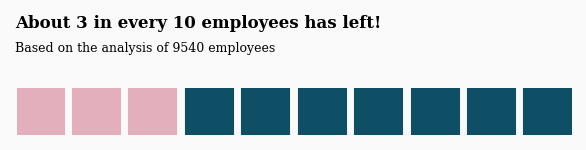

In [3]:
data = {'Left': 3, 'Employed':7}
background_color = "#fafafa" 
fig = plt.figure(figsize=(4, 2),dpi=150,facecolor=background_color,
    FigureClass=Waffle,
    rows=1,
    columns=10,
    values=data,
    colors=["#e3afbc", '#0e4f66'],
    legend={'loc': 2, 'bbox_to_anchor': (1, 1)},
    vertical=False
)

fig.text(0.035,0.78,'About 3 in every 10 employees has left!' ,fontfamily='serif',fontsize=8,fontweight='bold')
fig.text(0.035,0.70,'Based on the analysis of 9540 employees',fontfamily='serif',fontsize=6)
fig.gca().get_legend().remove()

fig.tight_layout()
plt.savefig('img/headline.png')
# plt.show()

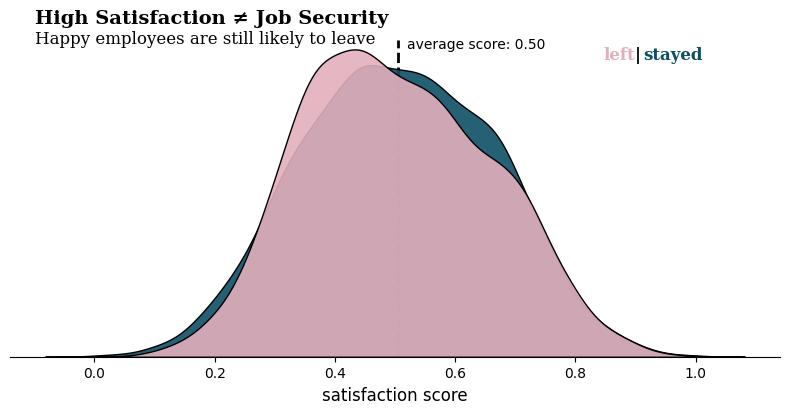

In [4]:
avg_sc = df['satisfaction'].mean()

fig, ax = plt.subplots(1,1, figsize=(8, 4))

ax.tick_params(axis='y', left=False)
ax.get_yaxis().set_visible(False)
for s in ["top","right","left"]:
    ax.spines[s].set_visible(False)

y = df[df['left'] == 'yes']
n = df[df['left'] == 'no']


sns.kdeplot(n['satisfaction'],ax=ax, color='#0e4f66', fill=True, linewidth=1, ec='black',alpha=0.9, zorder=3, legend=False)
sns.kdeplot(y['satisfaction'], ax=ax, color='#e3afbc', fill=True, linewidth=1, ec='black',alpha=0.9, zorder=3, legend=False)

ax.set_xlabel('satisfaction score', fontsize=12)
# ax.margins(x=0, y=0) 
ax.axvline(avg_sc, ymax=0.98, color='k', linestyle='dashed', linewidth=2)
ax.annotate("average score: {:.2f}".format(avg_sc), xy=(0.30, 1), xytext=(0.52, 2.35))
ax.grid(False)

fig.text(0.05, 0.99, 'High Satisfaction ≠ Job Security', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.05, 0.94,'Happy employees are still likely to leave',fontfamily='serif',fontsize=12)


fig.text(0.76,0.9,'left', fontweight="bold", fontfamily='serif', fontsize=12, color='#e3afbc')
fig.text(0.80,0.9,"|", fontweight="bold", fontfamily='serif', fontsize=12, color='black')
fig.text(0.81,0.9,"stayed", fontweight="bold", fontfamily='serif', fontsize=12, color='#0e4f66')

fig.tight_layout()
plt.savefig('img/sat score indicative.png', bbox_inches='tight')
plt.show()

## Different Employee Segments Based on Satisfaction Score
88% of employees scored below 0.7 — indicating widespread dissatisfaction

In [5]:
# variable for counting
df['count'] = 1

# grouping customers according to their satisfaction score
bins = [0, 0.4999,  0.6999, 1.1]
labels = ['0.0_0.499', '0.5_0.699', '0.7+']
df['satisfaction.group2'] = pd.cut(df['satisfaction'], bins, labels=labels, include_lowest=True)

# assigning descriptive names to segments based on satisfaction score
df['satisfaction.group3'] = np.where(df['satisfaction.group2'] == '0.0_0.499', 'detractors', 
                                     np.where(df['satisfaction.group2'] == '0.5_0.699', 'passives', 
                                              np.where(df['satisfaction.group2'] == '0.7+', 'promoters',
                                                       'unknown')))

df['satisfaction.group3'].value_counts(dropna=False, normalize=True)

df_seg = pd.DataFrame({'Satisfaction Score Range' : ['0.0_0.499', '0.5_0.699', '0.7+'], 
                      'Employee Segment' : ['detractors', 'passives', 'promoters'],
                       'Percentage' : ['49.8%', '38.1%', '12.1%']})
df_seg = df_seg.style.set_properties(**{'text-align': 'center'}); df_seg

,Satisfaction Score Range,Employee Segment,Percentage
0,0.0_0.499,detractors,49.8%
1,0.5_0.699,passives,38.1%
2,0.7+,promoters,12.1%


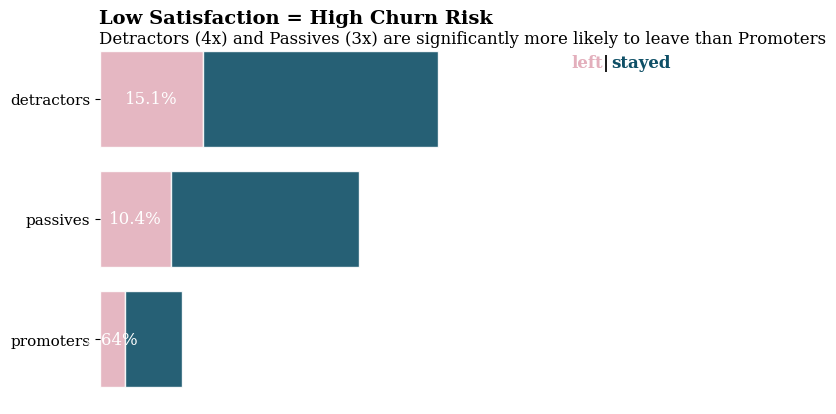

In [6]:
df_seg2 = (df[['satisfaction.group3', 'left', 'count']].groupby(['satisfaction.group3'])['left'].value_counts().unstack()).div(df['count'].sum())[['yes', 'no']].sort_values(by='yes', ascending=False)

fig, ax = plt.subplots(1,1,figsize=(8, 4)) 

ax.barh(df_seg2.index, df_seg2['yes'], ec='white',
        color='#e3afbc', alpha=0.9, label='left')
ax.barh(df_seg2.index, df_seg2['no'], left=df_seg2['yes'],ec='white',
        color='#0e4f66', alpha=0.9, label='stayed')


ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticks(range(len(df_seg2)))
ax.set_yticklabels(df_seg2.index, 
                   fontfamily='serif', 
                   fontsize=11)
ax.grid(False)

ax.invert_yaxis()

for i in df_seg2.index:
    ax.annotate(f"{df_seg2['yes'][i]*100:.3}%", 
                   xy=(df_seg2['yes'][i]/2, i),
                   va = 'center', ha='center',fontsize=12, fontweight='light', fontfamily='serif',
                   color='white')

for s in ['top', 'left', 'right', 'bottom']:
    ax.spines[s].set_visible(False)
    

fig.text(0.72,0.88,'left', fontweight="bold", fontfamily='serif', fontsize=12, color='#e3afbc')
fig.text(0.76,0.88,'|', fontweight="bold", fontfamily='serif', fontsize=12, color='black')
fig.text(0.77,0.88,'stayed', fontweight="bold", fontfamily='serif', fontsize=12, color='#0e4f66')

fig.text(0.13, 0.99, 'Low Satisfaction = High Churn Risk', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.13, 0.94,'Detractors (4x) and Passives (3x) are significantly more likely to leave than Promoters',fontfamily='serif',fontsize=12)


fig.tight_layout()
plt.savefig('img/high risk employees.png', bbox_inches='tight')
plt.show()

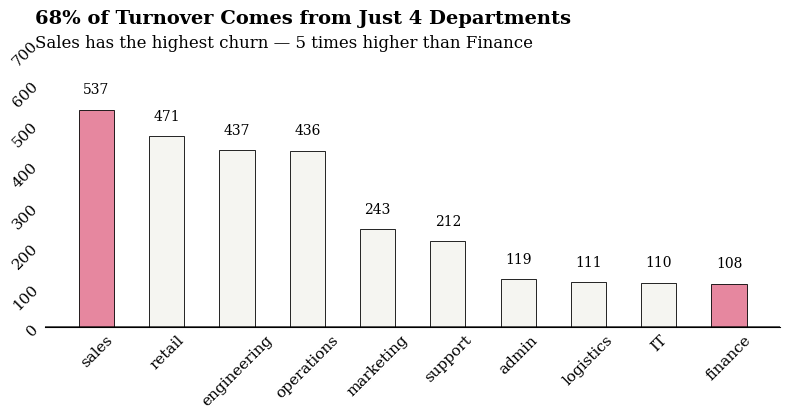

In [7]:
data = df[df['left']=='yes'].groupby('department')['count'].sum().sort_values(ascending=False)

# Plot
color_map = ['#f5f5f1' for _ in range(10)]
color_map[0]  = color_map[9] ='#e6879f' 


fig, ax = plt.subplots(1,1, figsize=(8, 4))
ax.bar(data.index, data, width=0.5,
       edgecolor='black',
       linewidth=0.6,color=color_map)

#annotations
for i in data.index:
    ax.annotate(f"{data[i]}", 
                   xy=(i, data[i] + 50), #i like to change this to roughly 5% of the highest cat
                   va = 'center', ha='center',fontweight='light', fontfamily='serif')



# Remove border from plot
for s in ['top', 'left', 'right']:
    ax.spines[s].set_visible(False)
    
# Tick labels
ax.set_xticklabels(data.index, fontfamily='serif', rotation=0)
ax.grid(False)

# Title and sub-title
fig.text(0.05, 1, '68% of Turnover Comes from Just 4 Departments', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.05,0.94,'Sales has the highest churn — 5 times higher than Finance',fontfamily='serif',fontsize=12)


grid_y_ticks = np.arange(0, 800, 100)
ax.set_yticks(grid_y_ticks)
ax.set_axisbelow(True)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation = 45, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(False), fontfamily='serif', rotation = 45, fontsize=11)

plt.axhline(y = 0, color = 'black', linewidth = 1.3, alpha = .7)

ax.tick_params(axis='both', which='major', labelsize=11)



ax.tick_params(axis=u'both', which=u'both',length=0)

fig.tight_layout()
plt.savefig('img/employees leaving.png', bbox_inches='tight')
plt.show()

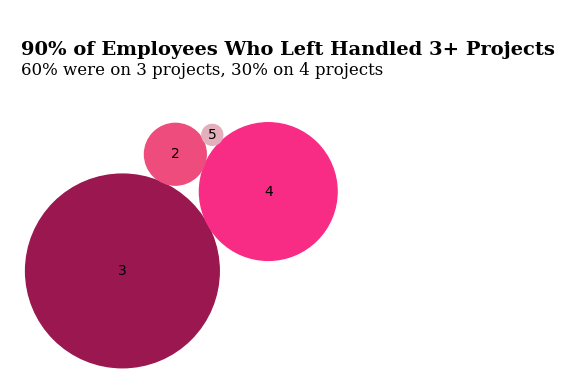

In [8]:
data = df[df['left']=='yes'].groupby('projects')['count'].sum().sort_values(ascending=False)

bubble_chart_data = {
    'index': data.index,
    'data': data.values,
    'color': [ '#9a1750', '#F92C85','#ee4c7c','#e3afbc',]
    
}

class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        idx_min = np.argmin(distance)
        return idx_min if type(idx_min) == np.ndarray else [idx_min]

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = (self.bubbles[i, :2] + orth *
                                      self.step_dist)
                        new_point2 = (self.bubbles[i, :2] - orth *
                                      self.step_dist)
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')


    
           
bubble_chart = BubbleChart(area=bubble_chart_data['data'],
                           bubble_spacing=0.1)

bubble_chart.collapse()

fig, ax =plt.subplots(subplot_kw=dict(aspect="equal"), figsize=(8, 4))
bubble_chart.plot(
    ax, bubble_chart_data['index'], bubble_chart_data['color'])
ax.axis("off")
ax.relim()
ax.autoscale_view()

fig.text(0.3, 0.85, '90% of Employees Who Left Handled 3+ Projects', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.3, 0.80,'60% were on 3 projects, 30% on 4 projects',fontfamily='serif',fontsize=12)


grid_y_ticks = np.arange(0, 80, 10)
ax.set_yticks(grid_y_ticks)
ax.set_axisbelow(True)
ax.set_xticklabels(ax.get_xticklabels(),fontfamily='serif', rotation = 45, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(False), fontfamily='serif', rotation = 45, fontsize=11)

ax.tick_params(axis='both', which='major', labelsize=12)


ax.tick_params(axis=u'both', which=u'both',length=0)

fig.tight_layout()
plt.savefig('img/workload bubble chart.png', bbox_inches='tight')
plt.show()

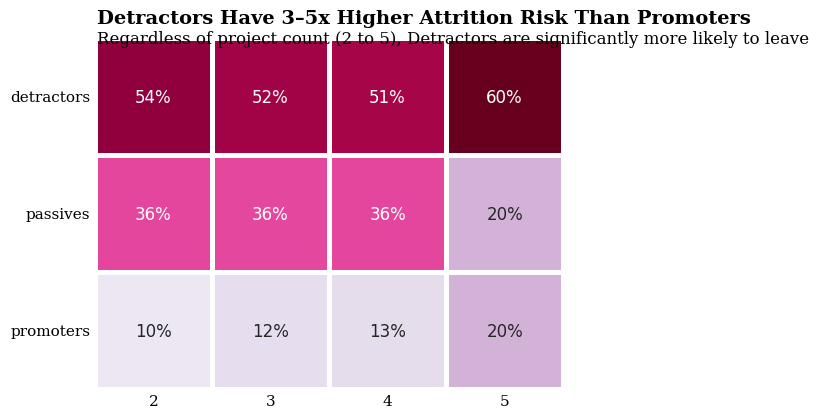

In [9]:
df_heatmap = df[df['left'] == 'yes']
df_heatmap1 = pd.crosstab(df_heatmap['projects'],df_heatmap['satisfaction.group3'],normalize = "index").T

cmap = plt.get_cmap('PuRd')
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

sns.heatmap(df_heatmap1,cmap=cmap,square=True, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.21, 1, 'Detractors Have 3–5x Higher Attrition Risk Than Promoters', fontweight='bold', fontfamily='serif', fontsize=14)   
fig.text(0.21, 0.95,'Regardless of project count (2 to 5), Detractors are significantly more likely to leave',fontfamily='serif',fontsize=12)

ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/workload heatmap.png', bbox_inches='tight')
plt.show()

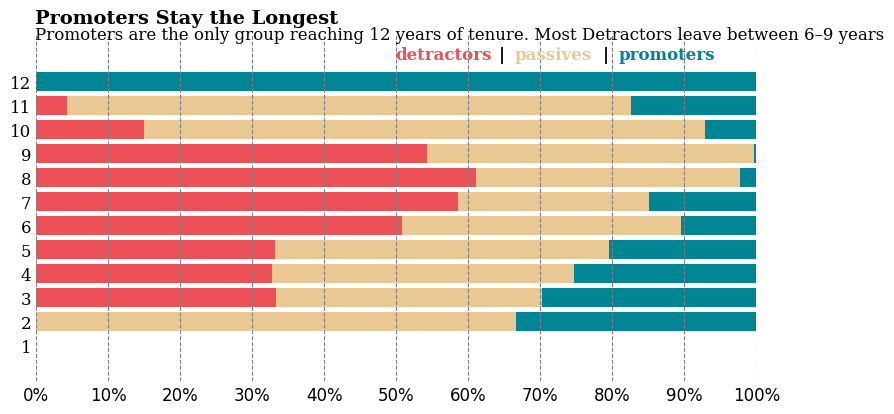

In [10]:
# variables
cross_tab_prop = pd.crosstab(index=df['tenure'],
                             columns=df['satisfaction.group3'],
                             normalize="index").sort_index(ascending=True)
labels = ['detractors', 'passives', 'promoters']
colors = ['#ed5158','#e9c893','#008594']
title = 'Video Game Sales By Platform and Region\n'
subtitle = 'Proportion of Games Sold by Region'
# def plot_stackedbar_p(df, labels, colors, title, subtitle):

fields = cross_tab_prop.columns.tolist()
    

fig, ax = plt.subplots(1,1,figsize=(8, 4))

# plot bars
left = len(cross_tab_prop) * [0]
for idx, name in enumerate(fields):
    plt.barh(cross_tab_prop.index, cross_tab_prop[name], left = left, color=colors[idx])
    left = left + cross_tab_prop[name]

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticklabels(cross_tab_prop.index, fontfamily='serif', fontsize=11)
# # remove spines
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
# format x ticks
xticks = np.arange(0,1.1,0.1)
xlabels = ['{}%'.format(i) for i in np.arange(0,101,10)]
plt.xticks(xticks, xlabels)
# adjust limits and draw grid lines
plt.ylim(-0.5, ax.get_yticks()[-1])
yticks = np.arange(1,13,1)
ylabels = [i for i in np.arange(1,13,1)]
plt.yticks(yticks, ylabels)
ax.xaxis.grid(color='gray', linestyle='dashed')
    
fig.text(0.5,0.90,'detractors', fontweight="bold", fontfamily='serif', fontsize=12, color='#ed5158')
fig.text(0.63,0.90,'|', fontweight="bold", fontfamily='serif', fontsize=12, color='black')
fig.text(0.65,0.90,'passives', fontweight="bold", fontfamily='serif', fontsize=12, color='#e9c893')
fig.text(0.76,0.90,'|', fontweight="bold", fontfamily='serif', fontsize=12, color='black')
fig.text(0.78,0.90,'promoters', fontweight="bold", fontfamily='serif', fontsize=12, color='#008594')

fig.text(0.05, 0.99, 'Promoters Stay the Longest', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.05, 0.95,'Promoters are the only group reaching 12 years of tenure. Most Detractors leave between 6–9 years', fontfamily='serif',fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis=u'both', which=u'both',length=0)
plt.tight_layout()
plt.savefig('img/all employee tenure.png', bbox_inches='tight')
plt.show()

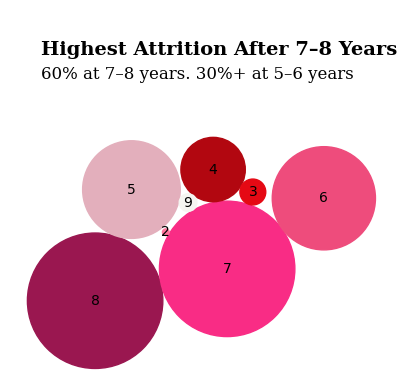

In [11]:
df['tenure'] = df['tenure'].astype('int64')
data = df[df['left']=='yes'].groupby('tenure')['count'].sum().sort_values(ascending=False)

bubble_chart_data = {
    'index': data.index,
    'data': data.values,
    'color': ['#9a1750', '#F92C85','#ee4c7c','#e3afbc', '#b20710', '#e50914','#f5f5f1','#FE759C',]
}

class BubbleChart:
    def __init__(self, area, bubble_spacing=0):
        """
        Setup for bubble collapse.

        Parameters
        ----------
        area : array-like
            Area of the bubbles.
        bubble_spacing : float, default: 0
            Minimal spacing between bubbles after collapsing.

        Notes
        -----
        If "area" is sorted, the results might look weird.
        """
        area = np.asarray(area)
        r = np.sqrt(area / np.pi)

        self.bubble_spacing = bubble_spacing
        self.bubbles = np.ones((len(area), 4))
        self.bubbles[:, 2] = r
        self.bubbles[:, 3] = area
        self.maxstep = 2 * self.bubbles[:, 2].max() + self.bubble_spacing
        self.step_dist = self.maxstep / 2

        # calculate initial grid layout for bubbles
        length = np.ceil(np.sqrt(len(self.bubbles)))
        grid = np.arange(length) * self.maxstep
        gx, gy = np.meshgrid(grid, grid)
        self.bubbles[:, 0] = gx.flatten()[:len(self.bubbles)]
        self.bubbles[:, 1] = gy.flatten()[:len(self.bubbles)]

        self.com = self.center_of_mass()

    def center_of_mass(self):
        return np.average(
            self.bubbles[:, :2], axis=0, weights=self.bubbles[:, 3]
        )

    def center_distance(self, bubble, bubbles):
        return np.hypot(bubble[0] - bubbles[:, 0],
                        bubble[1] - bubbles[:, 1])

    def outline_distance(self, bubble, bubbles):
        center_distance = self.center_distance(bubble, bubbles)
        return center_distance - bubble[2] - \
            bubbles[:, 2] - self.bubble_spacing

    def check_collisions(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        return len(distance[distance < 0])

    def collides_with(self, bubble, bubbles):
        distance = self.outline_distance(bubble, bubbles)
        idx_min = np.argmin(distance)
        return idx_min if type(idx_min) == np.ndarray else [idx_min]

    def collapse(self, n_iterations=50):
        """
        Move bubbles to the center of mass.

        Parameters
        ----------
        n_iterations : int, default: 50
            Number of moves to perform.
        """
        for _i in range(n_iterations):
            moves = 0
            for i in range(len(self.bubbles)):
                rest_bub = np.delete(self.bubbles, i, 0)
                # try to move directly towards the center of mass
                # direction vector from bubble to the center of mass
                dir_vec = self.com - self.bubbles[i, :2]

                # shorten direction vector to have length of 1
                dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))

                # calculate new bubble position
                new_point = self.bubbles[i, :2] + dir_vec * self.step_dist
                new_bubble = np.append(new_point, self.bubbles[i, 2:4])

                # check whether new bubble collides with other bubbles
                if not self.check_collisions(new_bubble, rest_bub):
                    self.bubbles[i, :] = new_bubble
                    self.com = self.center_of_mass()
                    moves += 1
                else:
                    # try to move around a bubble that you collide with
                    # find colliding bubble
                    for colliding in self.collides_with(new_bubble, rest_bub):
                        # calculate direction vector
                        dir_vec = rest_bub[colliding, :2] - self.bubbles[i, :2]
                        dir_vec = dir_vec / np.sqrt(dir_vec.dot(dir_vec))
                        # calculate orthogonal vector
                        orth = np.array([dir_vec[1], -dir_vec[0]])
                        # test which direction to go
                        new_point1 = (self.bubbles[i, :2] + orth *
                                      self.step_dist)
                        new_point2 = (self.bubbles[i, :2] - orth *
                                      self.step_dist)
                        dist1 = self.center_distance(
                            self.com, np.array([new_point1]))
                        dist2 = self.center_distance(
                            self.com, np.array([new_point2]))
                        new_point = new_point1 if dist1 < dist2 else new_point2
                        new_bubble = np.append(new_point, self.bubbles[i, 2:4])
                        if not self.check_collisions(new_bubble, rest_bub):
                            self.bubbles[i, :] = new_bubble
                            self.com = self.center_of_mass()

            if moves / len(self.bubbles) < 0.1:
                self.step_dist = self.step_dist / 2

    def plot(self, ax, labels, colors):
        """
        Draw the bubble plot.

        Parameters
        ----------
        ax : matplotlib.axes.Axes
        labels : list
            Labels of the bubbles.
        colors : list
            Colors of the bubbles.
        """
        for i in range(len(self.bubbles)):
            circ = plt.Circle(
                self.bubbles[i, :2], self.bubbles[i, 2], color=colors[i])
            ax.add_patch(circ)
            ax.text(*self.bubbles[i, :2], labels[i],
                    horizontalalignment='center', verticalalignment='center')


    
           
bubble_chart = BubbleChart(area=bubble_chart_data['data'],
                           bubble_spacing=0.1)

bubble_chart.collapse()

fig, ax = plt.subplots(subplot_kw=dict(aspect="equal"), figsize=(8, 4))
bubble_chart.plot(
    ax, bubble_chart_data['index'], bubble_chart_data['color'])
ax.axis("off")
ax.relim()
ax.autoscale_view()

fig.text(0.3, 0.85, 'Highest Attrition After 7–8 Years', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.3, 0.79,'60% at 7–8 years. 30%+ at 5–6 years', fontfamily='serif',fontsize=12)

grid_y_ticks = np.arange(0, 80, 10)
ax.set_yticks(grid_y_ticks)
ax.set_axisbelow(True)
ax.set_xticklabels(ax.get_xticklabels(),fontfamily='serif', rotation = 45, fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(False), fontfamily='serif', rotation = 45, fontsize=11)

ax.tick_params(axis='both', which='major', labelsize=12)

ax.tick_params(axis=u'both', which=u'both',length=0)

fig.tight_layout()
plt.savefig('img/tenure bubble chart.png', bbox_inches='tight')
plt.show()

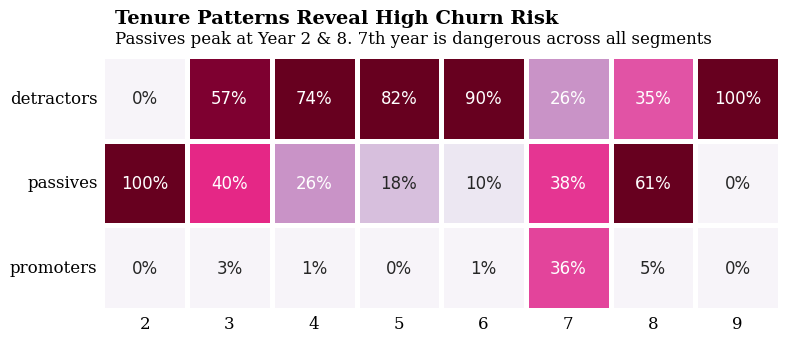

In [12]:
df['tenure'] = df['tenure'].astype('int64')
color_map = plt.get_cmap('PuRd')
df_tenure = df[df['left'] == 'yes']
df_heatmap0 = pd.crosstab(df_tenure['tenure'],df_tenure['satisfaction.group3'],normalize = "index").T

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

sns.heatmap(df_heatmap0,cmap=cmap,square=True, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.15, 0.9, 'Tenure Patterns Reveal High Churn Risk', fontweight='bold', fontfamily='serif', fontsize=14)   
fig.text(0.15, 0.85,'Passives peak at Year 2 & 8. 7th year is dangerous across all segments', fontfamily='serif',fontsize=12)


ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/years of service heatmap.png', bbox_inches='tight')
plt.show()

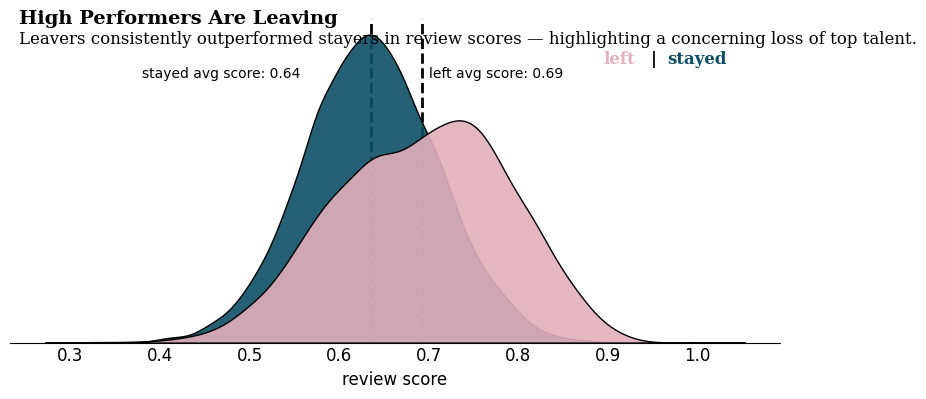

In [13]:
avg_rs_y = df[df['left'] == 'yes']['review'].mean()
avg_rs_n = df[df['left'] == 'no']['review'].mean()

fig, ax = plt.subplots(1,1, figsize=(8, 4))

ax.tick_params(axis='y', left=False)
ax.get_yaxis().set_visible(False)
for s in ["top","right","left"]:
    ax.spines[s].set_visible(False)

y = df[df['left'] == 'yes']
n = df[df['left'] == 'no']


sns.kdeplot(n['review'], ax=ax, color='#0e4f66', fill=True, linewidth=1, ec='black',alpha=0.9, zorder=3, legend=False)
sns.kdeplot(y['review'],ax=ax, color='#e3afbc', fill=True, linewidth=1, ec='black',alpha=0.9, zorder=3, legend=False)

ax.set_xlabel('review score', fontsize=12)
ax.grid(False)

ax.axvline(avg_rs_n, color='k', linestyle='dashed', linewidth=2)
ax.axvline(avg_rs_y, color='k', linestyle='dashed', linewidth=2)
ax.annotate("left avg score: {:.2f}".format(avg_rs_y), xy=(0.35, 1), xytext=(0.70, 4.6))
ax.annotate("stayed avg score: {:.2f}".format(avg_rs_n), xy=(0.35, 1), xytext=(0.38, 4.6))

fig.text(0.03, 0.95, 'High Performers Are Leaving', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.03, 0.90,'Leavers consistently outperformed stayers in review scores — highlighting a concerning loss of top talent.', fontfamily='serif',fontsize=12)

fig.text(0.76,0.85,'left', fontweight="bold", fontfamily='serif', fontsize=12, color='#e3afbc')
fig.text(0.82,0.85,"|", fontweight="bold", fontfamily='serif', fontsize=12, color='black')
fig.text(0.84,0.85,"stayed", fontweight="bold", fontfamily='serif', fontsize=12, color='#0e4f66')

fig.text(0.13,0.85,'',fontfamily='serif',fontsize=14,fontweight='bold')


ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis=u'both', which=u'both',length=0)

fig.tight_layout()
plt.savefig('img/review score indicative.png', bbox_inches='tight')
plt.show()

## Different Employee Segments Based on Review Score
74% of employees are Subpar or Solid performers, with only 28% classified as High Performers.

In [14]:
# grouping customers according to their review score
bins = [0,  0.5999, 0.6999,  1.1]
labels = ['0.0_0.599', '0.6_0.699', '0.7+']
df['review.group2'] = pd.cut(df['review'], bins, labels=labels, include_lowest=True)

# assigning descriptive names to segments based on review score
df['review.group3'] = np.where(df['review.group2'] == '0.0_0.599', 'subpar performers', 
                                     np.where(df['review.group2'] == '0.6_0.699', 'solid performers', 
                                              np.where(df['review.group2'] == '0.7+', 'high performers',
                                                       'unknown')))

df_rev = pd.DataFrame({'Review Score Range' : ['0.0_0.599', '0.6_0.699', '0.7+'], 
                      'Employee Segment' : ['subpar performers', 'solid performers', 'high performers '],
                       'Percentage' : ['27.9%', '43.9%',  '28.2%']})
df_rev = df_rev.style.set_properties(**{'text-align': 'center'}); df_rev

,Review Score Range,Employee Segment,Percentage
0,0.0_0.599,subpar performers,27.9%
1,0.6_0.699,solid performers,43.9%
2,0.7+,high performers,28.2%


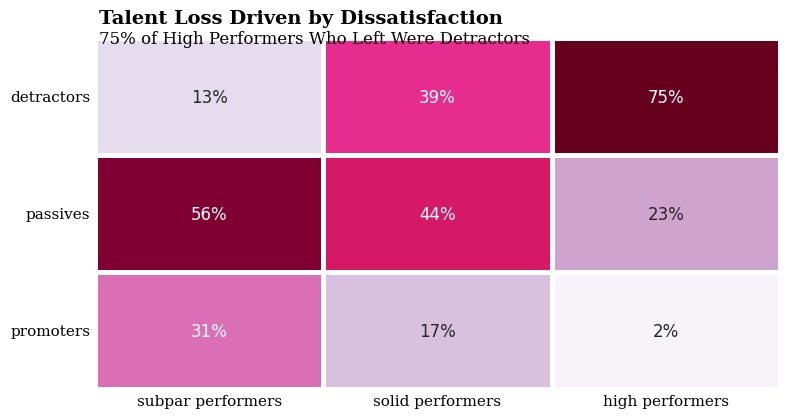

In [15]:
df_review = df[df['left'] == 'yes']
df_heatmap3 = pd.crosstab(df_review['review.group3'],df_review['satisfaction.group3'],normalize = "index").T
df_heatmap3 = df_heatmap3[['subpar performers','solid performers', 'high performers']]; df_heatmap3

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

sns.heatmap(df_heatmap3,cmap=cmap,square=False, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.13, 1, 'Talent Loss Driven by Dissatisfaction', fontweight='bold', fontfamily='serif', fontsize=14)
fig.text(0.13, 0.95,'75% of High Performers Who Left Were Detractors', fontfamily='serif',fontsize=12)



# fig.text(1.1,0.77, 'Key Insight', fontsize=14, fontweight='bold', fontfamily='serif')

# fig.text(1.1, 0.35, '''
# 75% of the high performing employees 
# who left were detractors.

# Passives who left were predominantly 
# subpar performers and solid performers.
# ''' , fontsize=12, fontweight='light', fontfamily='serif')

# import matplotlib.lines as lines
# l1 = lines.Line2D([1, 1], [0, 1], transform=fig.transFigure, figure=fig,color='black',lw=0.2)
# fig.lines.extend([l1])

ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/review tier heatmap.png', bbox_inches='tight')
plt.show()

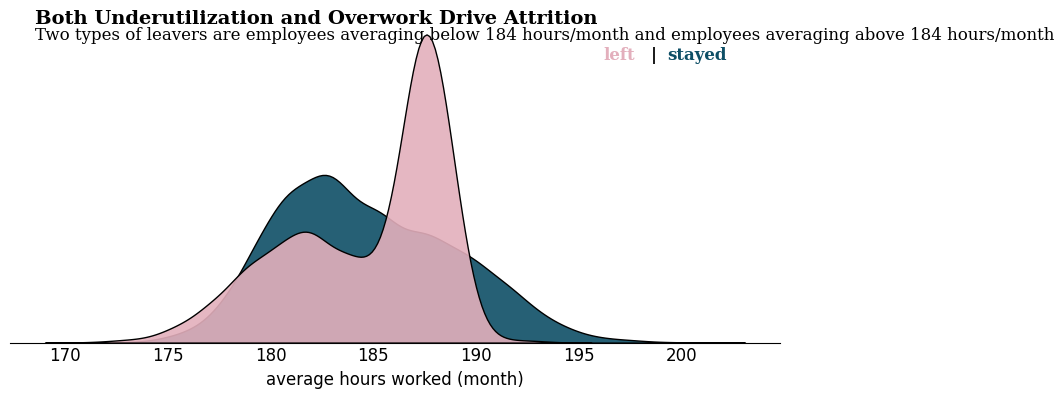

In [16]:
avg_hm_y = df[df['left'] == 'yes']['avg_hrs_month'].mean()
avg_hm_n = df[df['left'] == 'no']['avg_hrs_month'].mean()

fig, ax = plt.subplots(1,1, figsize=(8, 4))

ax.tick_params(axis='y', left=False)
ax.get_yaxis().set_visible(False)
for s in ["top","right","left"]:
    ax.spines[s].set_visible(False)

y = df[df['left'] == 'yes']
n = df[df['left'] == 'no']

sns.kdeplot(n['avg_hrs_month'],ax=ax, color='#0e4f66', shade=True, linewidth=1, ec='black',alpha=0.9, zorder=3, legend=False)
sns.kdeplot(y['avg_hrs_month'], ax=ax, color='#e3afbc', shade=True, linewidth=1, ec='black',alpha=0.9, zorder=3, legend=False)

ax.set_xlabel('average hours worked (month)', fontsize=12)

fig.text(0.05, 0.95, 'Both Underutilization and Overwork Drive Attrition', fontsize=14, fontweight='bold', fontfamily='serif')
fig.text(0.05, 0.91,'Two types of leavers are employees averaging below 184 hours/month and employees averaging above 184 hours/month', fontfamily='serif',fontsize=12)

fig.text(0.76,0.86,'left', fontweight="bold", fontfamily='serif', fontsize=12, color='#e3afbc')
fig.text(0.82,0.86,"|", fontweight="bold", fontfamily='serif', fontsize=12, color='black')
fig.text(0.84,0.86,"stayed", fontweight="bold", fontfamily='serif', fontsize=12, color='#0e4f66')


ax.tick_params(axis='both', which='major', labelsize=12)
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/hours worked density plot.png', bbox_inches='tight')
plt.show()

In [17]:
# grouping customers according to their satisfaction score
bins = [0,  184, 220]
labels = ['0_184.99', '185+']
df['avg_hrs_month.group2'] = pd.cut(df['avg_hrs_month'], bins, labels=labels, include_lowest=True)

# assigning descriptive names to segments based on satisfaction score
df['avg_hrs_month.group3'] = np.where(df['avg_hrs_month.group2'] == '0_184.99', 'short-hour workers', 
                                     np.where(df['avg_hrs_month.group2'] == '185+', 'long-hour workers', 
                                                       'unknown'))

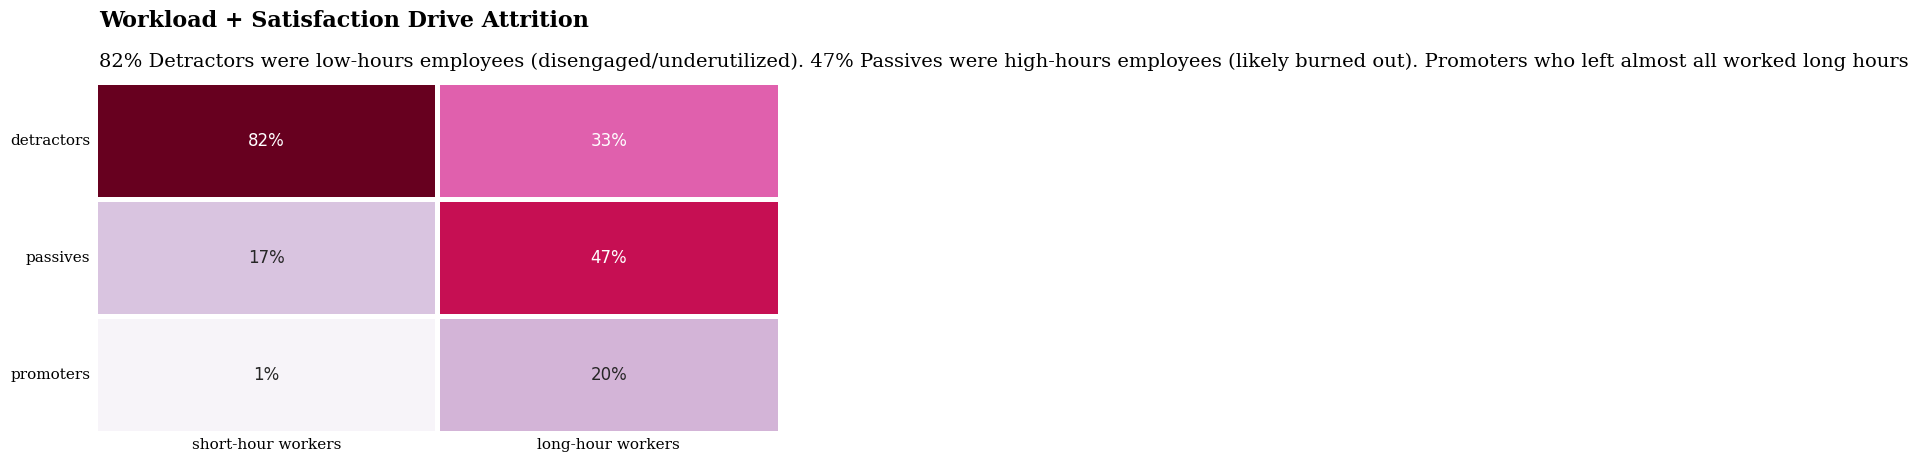

In [18]:
df_avg_hrs = df[df['left'] == 'yes']
df_heatmap4 = pd.crosstab(df_avg_hrs['avg_hrs_month.group3'],df_avg_hrs['satisfaction.group3'],normalize = "index").T
df_heatmap4 = df_heatmap4.sort_values(by='avg_hrs_month.group3', axis=1, ascending=False)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

sns.heatmap(df_heatmap4,cmap=cmap,square=False, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.13, 1.1, 'Workload + Satisfaction Drive Attrition', fontweight='bold', fontfamily='serif', fontsize=16)   
fig.text(0.13, 1.0,'82% Detractors were low-hours employees (disengaged/underutilized). 47% Passives were high-hours employees (likely burned out). Promoters who left almost all worked long hours', fontfamily='serif',fontsize=14)

ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/hours worked by satisfaction segment.png', bbox_inches='tight')
plt.show()

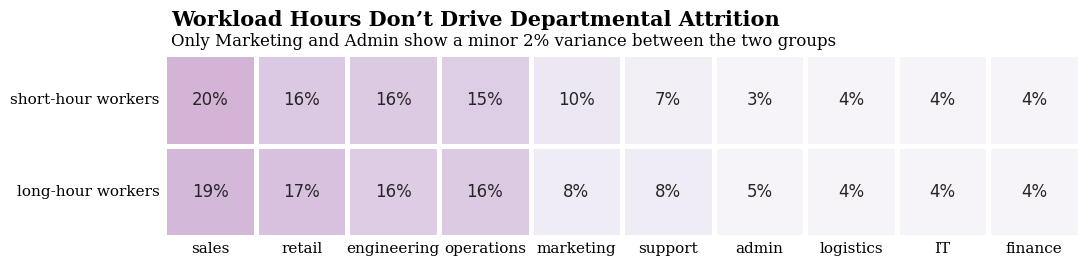

In [19]:
department_order = ['sales', 'retail', 'engineering', 'operations', 'marketing', 'support', 'admin', 'logistics', 'IT', 'finance']
df_heatmap7 = pd.crosstab(df_avg_hrs['avg_hrs_month.group3'],df_avg_hrs['department'],normalize = "index")[department_order].sort_index(ascending=False)

fig, ax = plt.subplots(1, 1, figsize=(11, 4))

sns.heatmap(df_heatmap7,cmap=cmap,square=True, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.16, 0.8, 'Workload Hours Don’t Drive Departmental Attrition', fontweight='bold', fontfamily='serif', fontsize=15)   
fig.text(0.16, 0.75,'Only Marketing and Admin show a minor 2% variance between the two groups', fontfamily='serif',fontsize=12)


ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/department and hours.png', bbox_inches='tight')
plt.show()

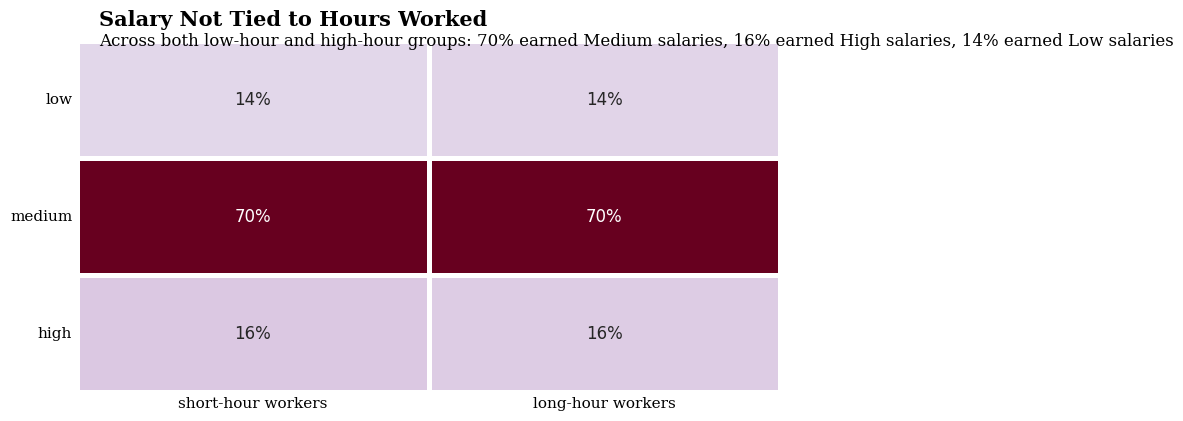

In [20]:
df_heatmap5 = pd.crosstab(df_avg_hrs['avg_hrs_month.group3'],df_avg_hrs['salary'],normalize = "index")[['low', 'medium', 'high']].sort_index(ascending=False).T
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

sns.heatmap(df_heatmap5,cmap=cmap,square=False, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.13, 1, 'Salary Not Tied to Hours Worked', fontweight='bold', fontfamily='serif', fontsize=15)   
fig.text(0.13, 0.95,'Across both low-hour and high-hour groups: 70% earned Medium salaries, 16% earned High salaries, 14% earned Low salaries', fontfamily='serif',fontsize=12)


ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/segment and salary levels.png', bbox_inches='tight')
plt.show()

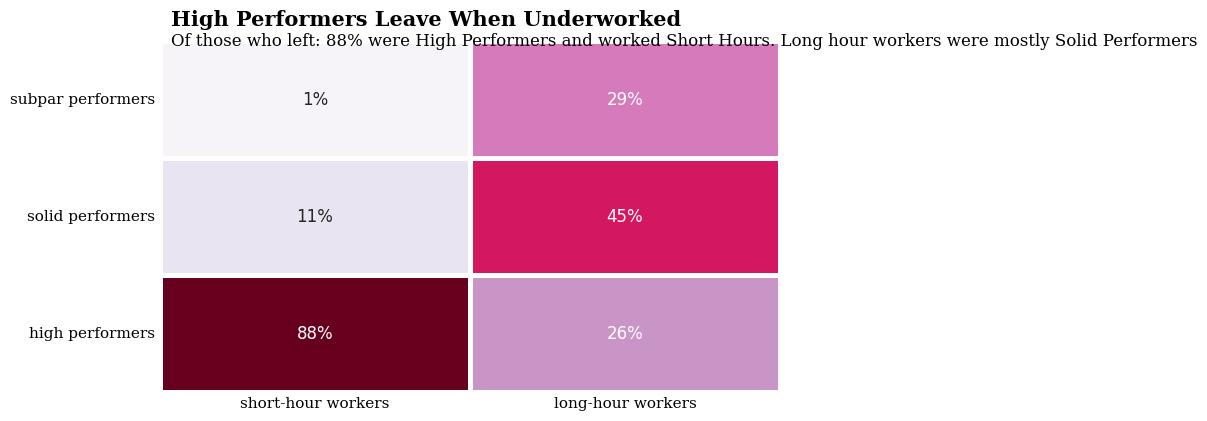

In [21]:
df_heatmap6 = pd.crosstab(df_avg_hrs['avg_hrs_month.group3'],df_avg_hrs['review.group3'],normalize = "index")[['subpar performers', 'solid performers', 'high performers']].sort_index(ascending=False).T
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

sns.heatmap(df_heatmap6,cmap=cmap,square=False, linewidth=2.5,cbar=False,
            annot=True,fmt='1.0%',vmax=.6,vmin=0.05,ax=ax,annot_kws={"fontsize":12})

ax.spines['top'].set_visible(False)


fig.text(0.22, 1, 'High Performers Leave When Underworked', fontweight='bold', fontfamily='serif', fontsize=15)   
fig.text(0.22, 0.95,'Of those who left: 88% were High Performers and worked Short Hours. Long hour workers were mostly Solid Performers', fontfamily='serif',fontsize=12)

ax.set_yticklabels(ax.get_yticklabels(), fontfamily='serif', rotation = 0, fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), fontfamily='serif', rotation=0, fontsize=11)

ax.set_ylabel('')    
ax.set_xlabel('')
ax.tick_params(axis=u'both', which=u'both',length=0)

plt.tight_layout()
plt.savefig('img/review tier and hours.png', bbox_inches='tight')
plt.show()

#### High Performers Received No Bonuses
This pattern holds across all satisfaction segments (Detractors, Passives, and Promoters) among employees who left

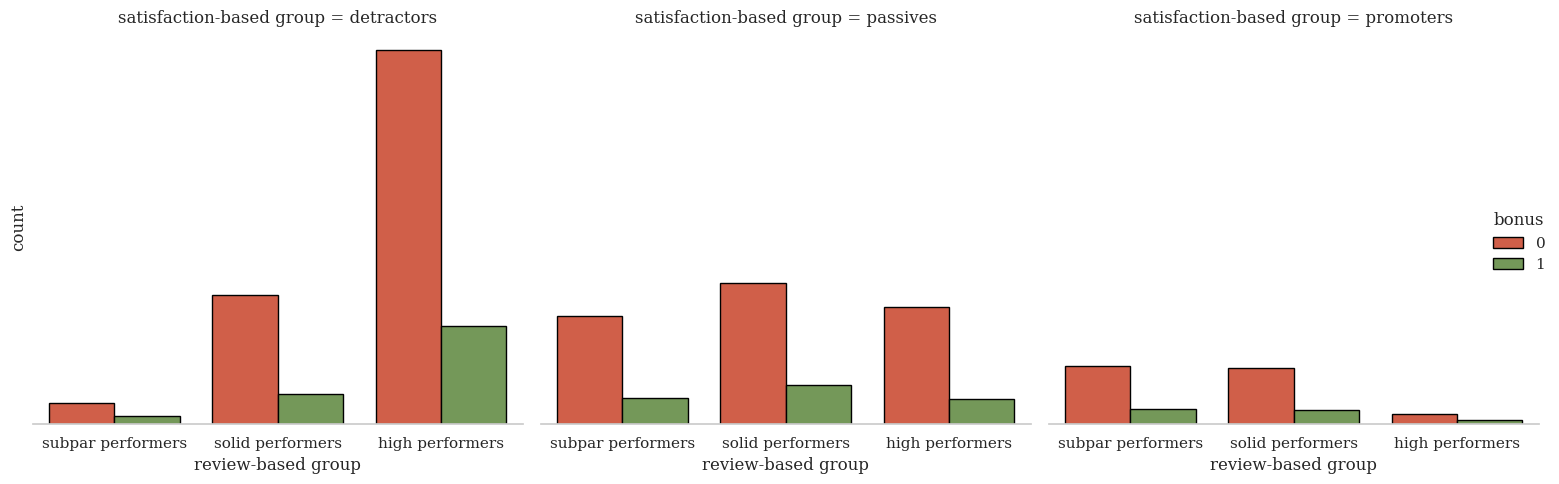

In [22]:
df_promo_bonus = df[df['left'] == 'yes'].copy()
df_promo_bonus.rename(columns={'review.group3':'review-based group', 'satisfaction.group3':'satisfaction-based group'}, inplace=True)

# df_promo_bonus['promoted'] = df_promo_bonus['promoted'].replace({0:'no', 1:'yes'})
# df_promo_bonus['bonus'] = df_promo_bonus['bonus'].replace({0:'no', 1:'yes'})

df_promo_bonus.loc[:, 'promoted'] = df_promo_bonus['promoted'].replace({'0': 'no', '1': 'yes'})   
df_promo_bonus.loc[:, 'bonus'] = df_promo_bonus['bonus'].replace({'0': 'no', '1': 'yes'})

# sns.set(fontsize=11)
sns.set_theme(style="whitegrid", font_scale=1, font='serif')
g=sns.catplot(x="review-based group", hue = "bonus", kind = 'count', col = "satisfaction-based group", order=['subpar performers', 'solid performers', 'high performers'],
    hue_order=None, col_order=['detractors', 'passives', 'promoters'],  data = df_promo_bonus, palette=['#e65032', '#73a24e'], ec='black') 
g.despine(left = True)

g.set(yticks=[])

plt.tight_layout()
plt.savefig('img/bonus and scores.png', bbox_inches='tight')
plt.show()

#### Lack of Promotion May Be Driving Attrition
Very few Solid and High Performers were promoted in the past 24 months, regardless of whether they were Detractors, Passives, or Promoters

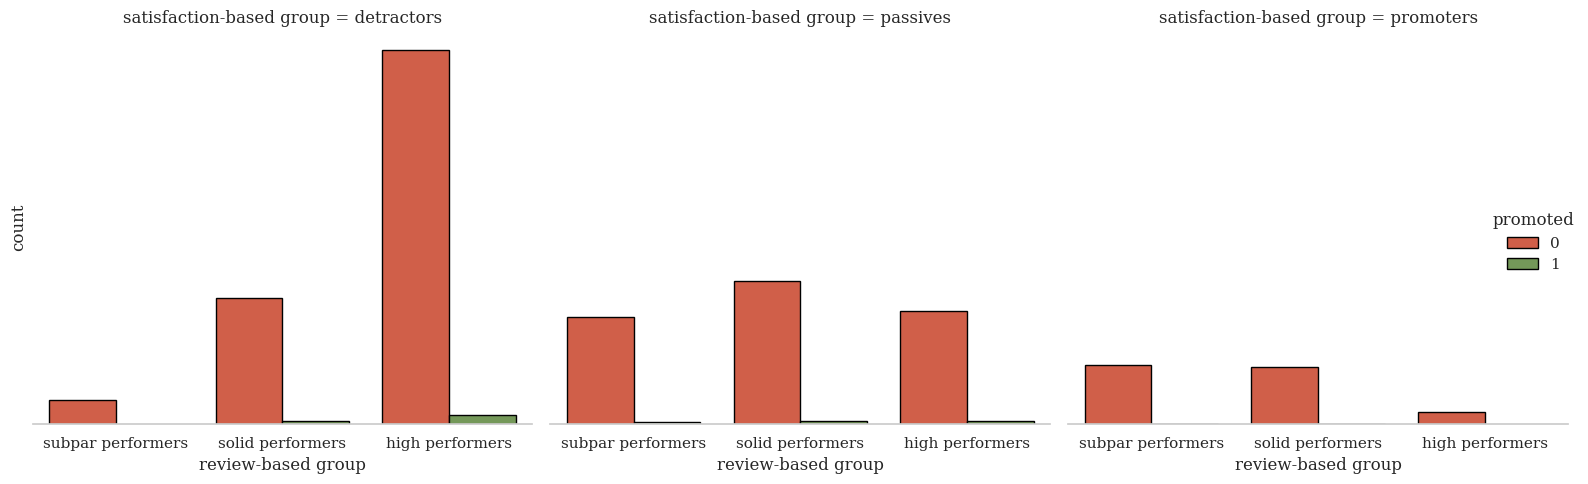

In [23]:
sns.set_theme(style="whitegrid", font_scale=1, font='serif')
g=sns.catplot(x="review-based group", hue = "promoted", kind = 'count', col = "satisfaction-based group", order=['subpar performers', 'solid performers', 'high performers'],
    hue_order=None, col_order=['detractors', 'passives', 'promoters'], sharey = True, data = df_promo_bonus, palette=['#e65032', '#73a24e'], ec='black') 
g.despine(left = True)

g.set(yticks=[])

plt.tight_layout()
plt.savefig('img/promotion and scores.png', bbox_inches='tight')
plt.show()